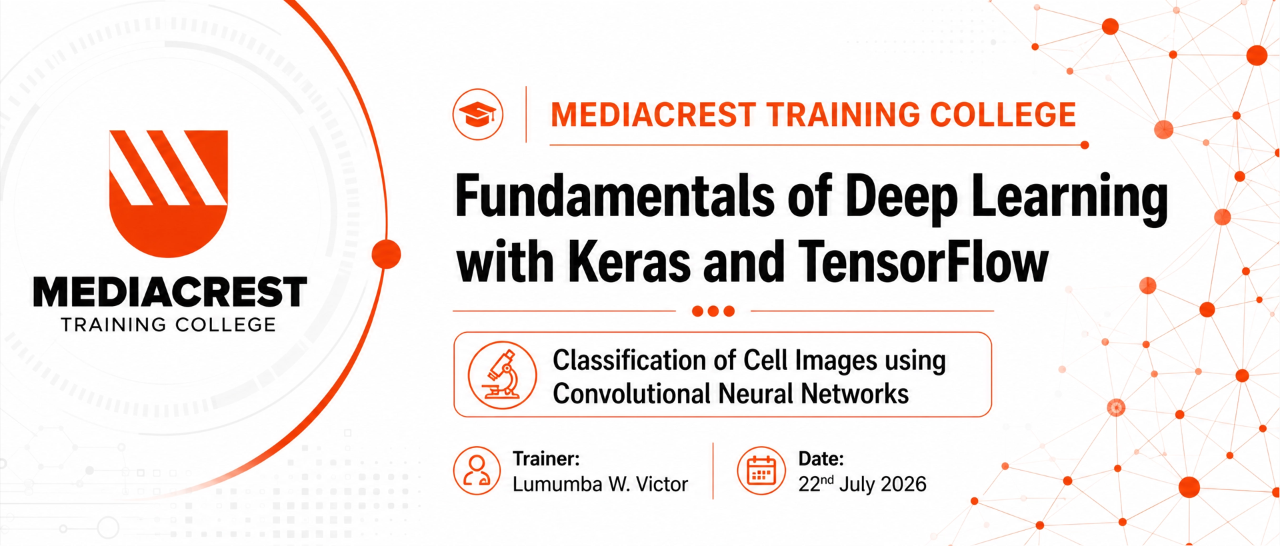

<div style="text-align:center;">

<h1 style="color:#0B5394; font-family:Georgia; font-size:38px;">
Integrated Explainable Artificial Intelligence and Deep Learning Framework
</h1>

<h2 style="color:#C00000; font-family:'Palatino Linotype'; font-size:28px;">
for Automated Classification of Malaria Infection Using
Microscopic Blood Smear Images
</h2>

<br>

<p style="font-size:18px; color:gray; font-family:Calibri;">
A Comprehensive Deep Learning and Explainable AI Framework for Malaria Diagnosis
using Microscopic Blood Smear Images
</p>

</div>

## **DEEP LEARNING USING EXTERNAL MALARIA DATASET**

In [1]:
# !pip install opencv-python

## **Imports the Required Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import random
import seaborn as sns
from collections import Counter
import random
import warnings
warnings.filterwarnings('ignore')

## Evaluation Metrics**
import tensorflow as tf
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, auc, precision_recall_curve, 
                             roc_auc_score, matthews_corrcoef, cohen_kappa_score)
from sklearn.model_selection import train_test_split

## **Configuration**

In [2]:
DATADIR = r"D:\Research Workshop and Seminars and Trainings\MEDIACREST COLLEGE\Data Analysis and Fundamentals of AI-July Intake\Session - Week6\cell_images"
CATEGORIES = ["Parasitized", "Uninfected"]

## **View a single Parasitized image**

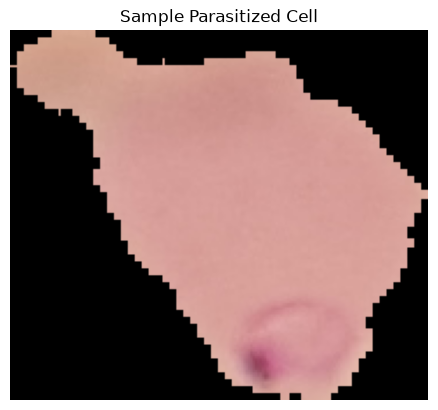

In [3]:
parasitized_images = os.listdir(os.path.join(DATADIR, "Parasitized"))
img_name = parasitized_images[100] 
img_array = cv2.imread(os.path.join(DATADIR, "Parasitized", img_name), cv2.IMREAD_COLOR)
plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
plt.title("Sample Parasitized Cell")
plt.axis('off')
plt.show()

## **View a random Uninfected image**

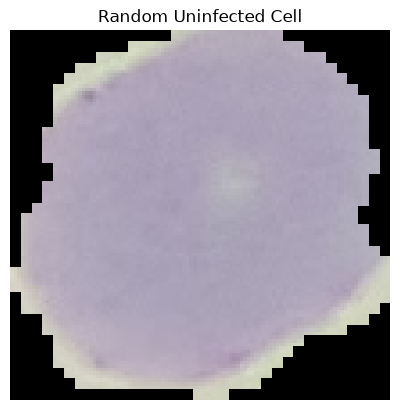

In [4]:
uninfected_images = os.listdir(os.path.join(DATADIR, "Uninfected"))
img_name = random.choice(uninfected_images)
img_array = cv2.imread(os.path.join(DATADIR, "Uninfected", img_name), cv2.IMREAD_COLOR)
plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
plt.title("Random Uninfected Cell")
plt.axis('off')
plt.show()

## **View multiple random images**

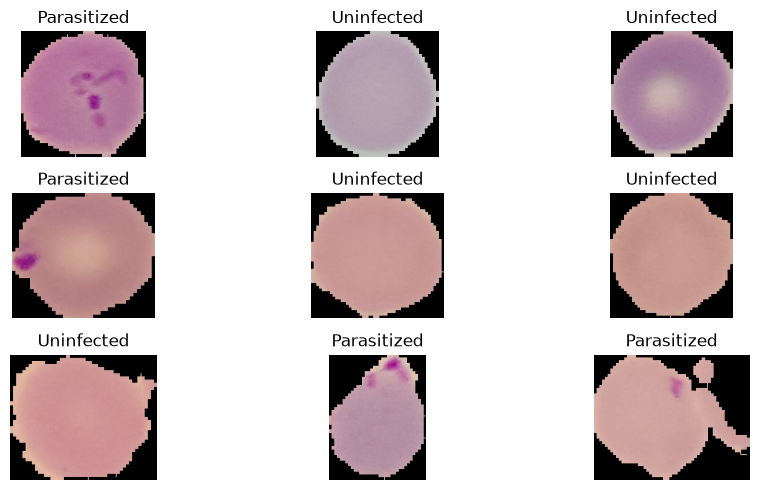

In [5]:
plt.figure(figsize=(10, 5))
for i in range(9):
    category = random.choice(CATEGORIES)
    path = os.path.join(DATADIR, category)
    img_list = os.listdir(path)
    img_name = random.choice(img_list)
    img_array = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_COLOR)
    
    plt.subplot(3, 3, i+1)
    plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
    plt.title(category)
    plt.axis("off")
plt.tight_layout()
plt.show()

## **View the Data as an Array**

[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]
Image Shape: (136, 169, 3)


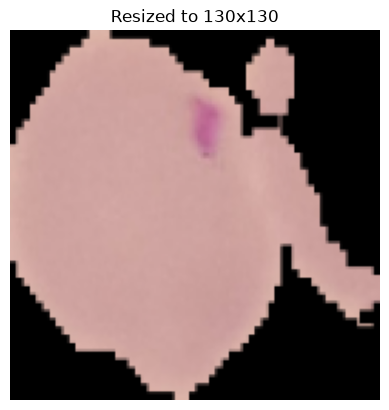

In [6]:
print(img_array)
print(f"Image Shape: {img_array.shape}")

# Cell 8: Resize the images
IMG_SIZE = 130  # Standard size for this dataset
new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(cv2.cvtColor(new_array, cv2.COLOR_BGR2RGB))
plt.title(f"Resized to {IMG_SIZE}x{IMG_SIZE}")
plt.axis('off')
plt.show()

## **2. Train the Model (Data Preparation)**

In [7]:
print("\n" + "="*80)
print("SECTION 2: DATASET DESCRIPTION & EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)
EDA_SAVE_DIR = "results/eda"
os.makedirs(EDA_SAVE_DIR, exist_ok=True)


SECTION 2: DATASET DESCRIPTION & EXPLORATORY DATA ANALYSIS (EDA)


## **2.2 DATASET CHARACTERIZATION**

In [8]:
print("\n[2.2] Dataset Characterization...")

total_images = 0
class_counts = {}
image_dimensions = []
color_channels = None

# Sample 500 images to check dimension distribution and RGB stats (faster than scanning all 27k)
sample_size = 500 
sample_images_paths = []

for category in CATEGORIES:
    category_path = os.path.join(DATADIR, category)
    images = os.listdir(category_path)
    class_counts[category] = len(images)
    total_images += len(images)
    
    # Get dimensions and channels from the first image
    first_img = cv2.imread(os.path.join(category_path, images[0]))
    if first_img is not None:
        if color_channels is None:
            color_channels = first_img.shape[2] if len(first_img.shape) == 3 else 1
            
    # Collect random samples for dimension/pixel analysis
    sampled_imgs = random.sample(images, min(sample_size, len(images)))
    for img_name in sampled_imgs:
        sample_images_paths.append(os.path.join(category_path, img_name))

# Analyze sampled images for dimensions
print(f"Analyzing {len(sample_images_paths)} sampled images for dimension distribution...")
for img_path in sample_images_paths:
    img = cv2.imread(img_path)
    if img is not None:
        image_dimensions.append(img.shape[:2]) # Store (height, width)

# Calculate dimension statistics
heights = [dim[0] for dim in image_dimensions]
widths = [dim[1] for dim in image_dimensions]

# Print Characterization Report (For your paper text)
print("\n" + "-"*50)
print("DATASET CHARACTERIZATION REPORT")
print("-"*50)
print(f"Total number of images: {total_images:,}")
print(f"Number of infected (Parasitized) images: {class_counts['Parasitized']:,}")
print(f"Number of healthy (Uninfected) images: {class_counts['Uninfected']:,}")
print(f"Color channels: {color_channels} (RGB)")
print(f"Image dimensions (Sampled):")
print(f"  - Height: Min={min(heights)}, Max={max(heights)}, Mean={np.mean(heights):.1f}")
print(f"  - Width:  Min={min(widths)}, Max={max(widths)}, Mean={np.mean(widths):.1f}")
print(f"Class Distribution:")
for cat, count in class_counts.items():
    print(f"  - {cat}: {count} ({count/total_images*100:.2f}%)")
print("-"*50)


[2.2] Dataset Characterization...
Analyzing 1000 sampled images for dimension distribution...

--------------------------------------------------
DATASET CHARACTERIZATION REPORT
--------------------------------------------------
Total number of images: 27,560
Number of infected (Parasitized) images: 13,780
Number of healthy (Uninfected) images: 13,780
Color channels: 3 (RGB)
Image dimensions (Sampled):
  - Height: Min=61, Max=385, Mean=132.3
  - Width:  Min=73, Max=247, Mean=132.1
Class Distribution:
  - Parasitized: 13780 (50.00%)
  - Uninfected: 13780 (50.00%)
--------------------------------------------------


## **2.3 EXPLORATORY DATA ANALYSIS (EDA)**

### **FIGURE 1: Class Distribution Plot**


[2.3] Generating Exploratory Data Analysis (EDA) Plots...


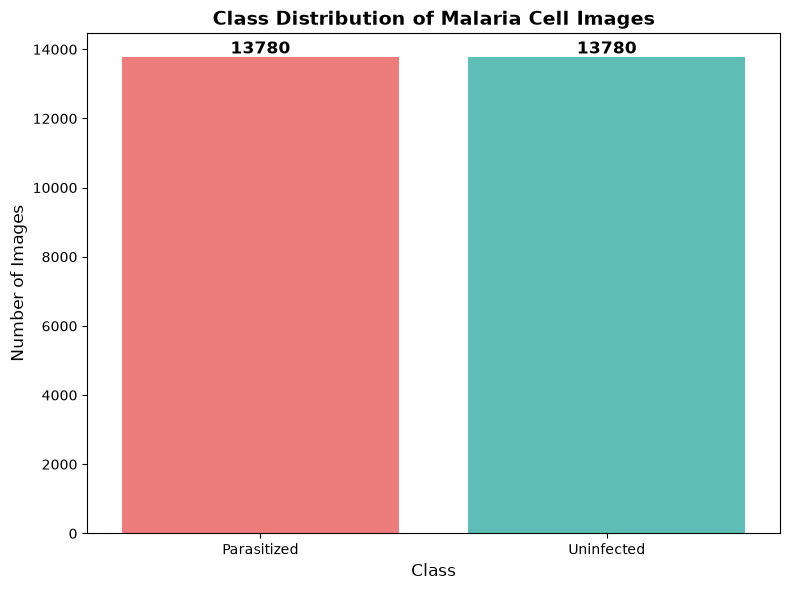

In [9]:
print("\n[2.3] Generating Exploratory Data Analysis (EDA) Plots...")
plt.figure(figsize=(8, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette=['#FF6B6B', '#4ECDC4'])
plt.title('Class Distribution of Malaria Cell Images', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12)
plt.xlabel('Class', fontsize=12)
for i, v in enumerate(class_counts.values()):
    plt.text(i, v + 100, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EDA_SAVE_DIR, 'fig1_class_distribution.png'), dpi=300)
plt.show()

### **FIGURE 2: Representative Infected and Healthy Cells**

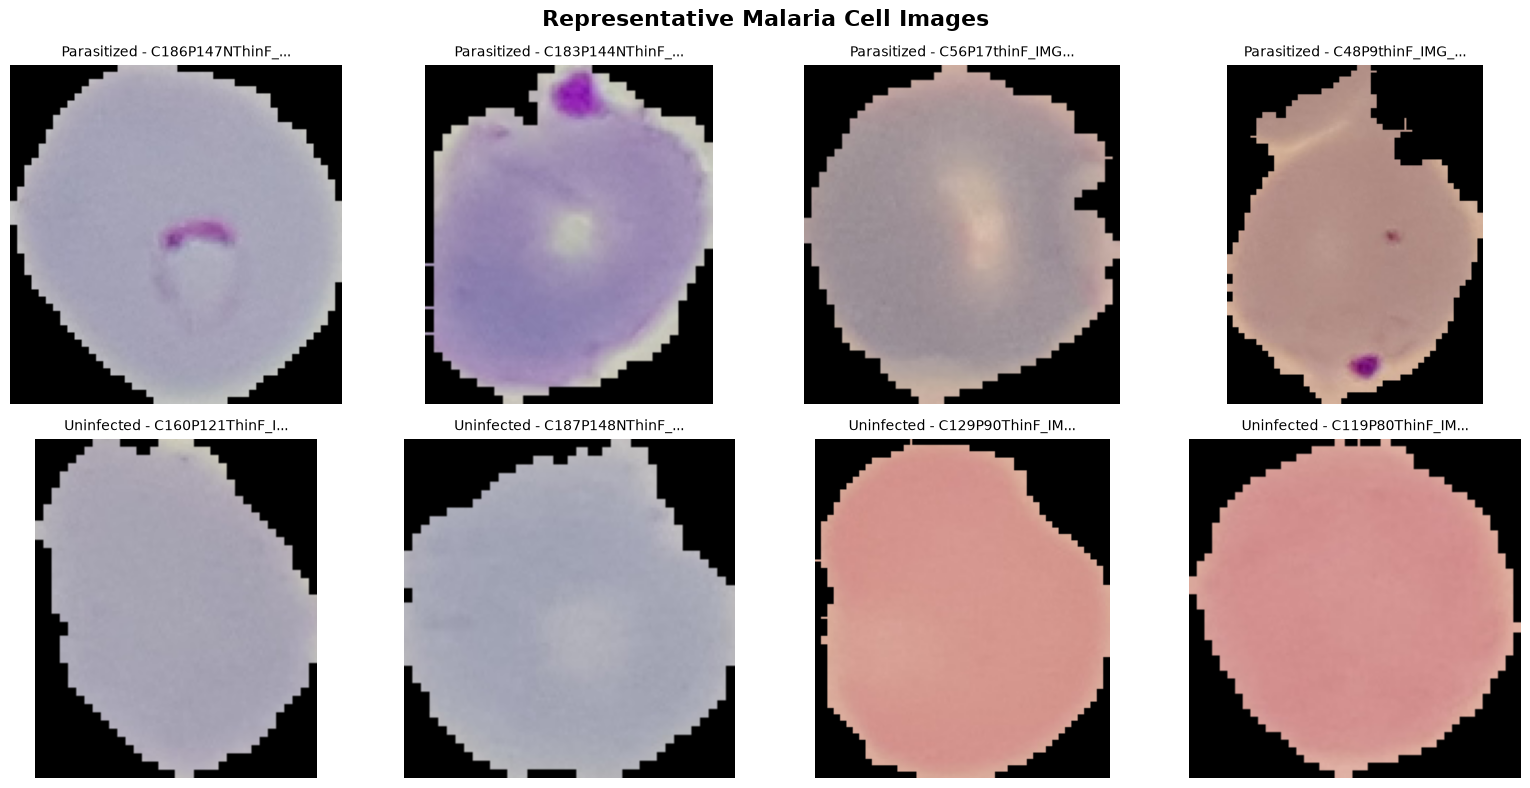

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Representative Malaria Cell Images', fontsize=16, fontweight='bold')

for idx, category in enumerate(CATEGORIES):
    category_path = os.path.join(DATADIR, category)
    images = os.listdir(category_path)
    sampled_imgs = random.sample(images, 4)
    
    for i, img_name in enumerate(sampled_imgs):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx, i].imshow(img_rgb)
        axes[idx, i].set_title(f"{category} - {img_name[:15]}...", fontsize=10)
        axes[idx, i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(EDA_SAVE_DIR, 'fig2_representative_cells.png'), dpi=300)
plt.show()

### **FIGURE 3: Image Dimension Distribution**

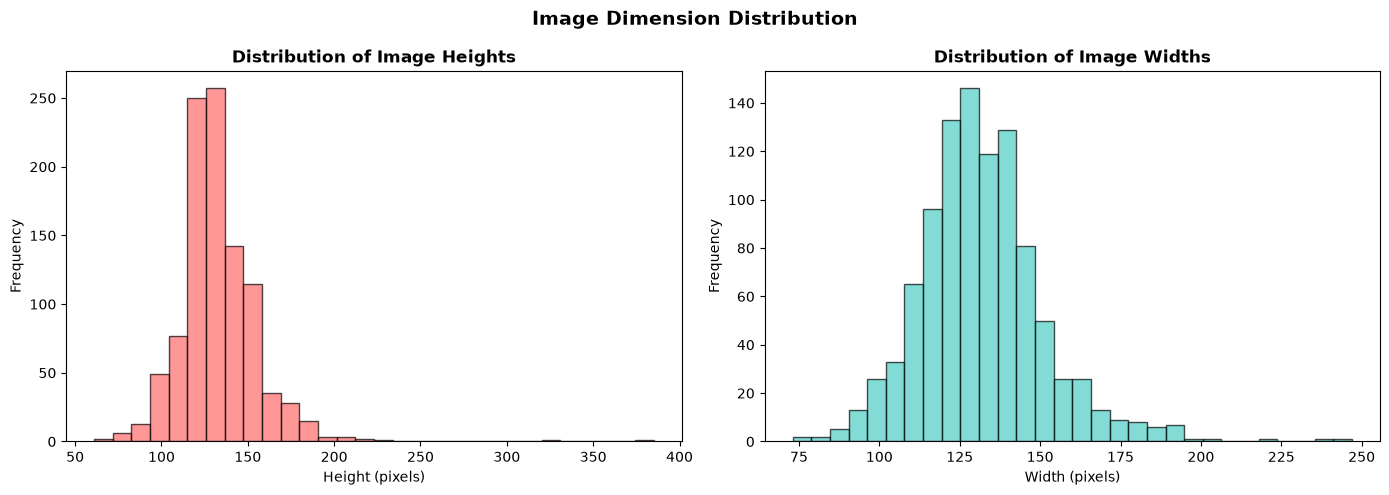

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(heights, bins=30, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Image Heights', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Height (pixels)')
axes[0].set_ylabel('Frequency')

axes[1].hist(widths, bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Image Widths', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Width (pixels)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Image Dimension Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EDA_SAVE_DIR, 'fig3_dimension_distribution.png'), dpi=300)
plt.show()

### **FIGURES 4 & 5: Pixel Intensity & RGB Channel Distributions**

Calculating pixel intensity and RGB distributions (sampling 100 images)...


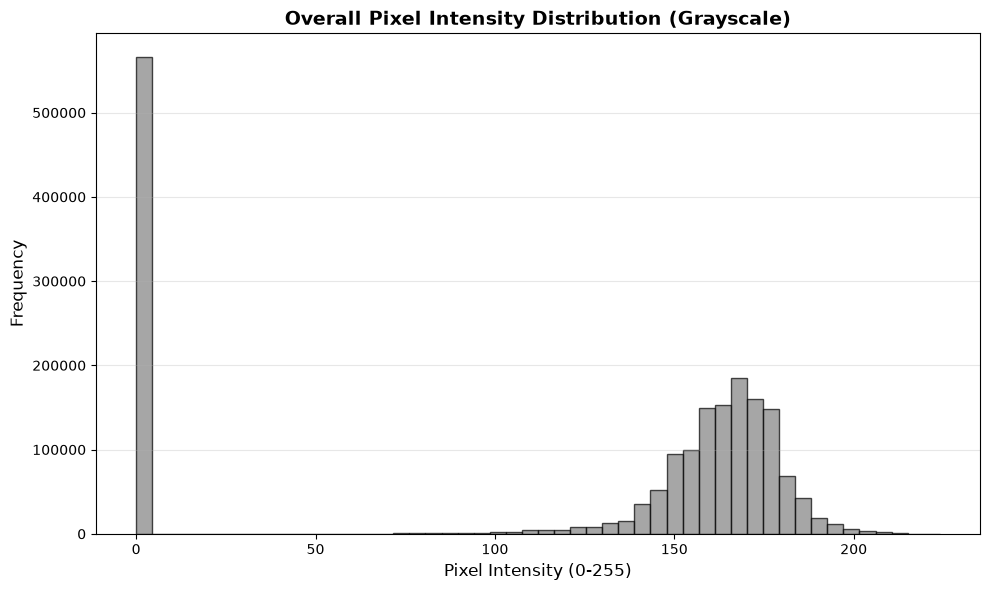

In [12]:
# Collect pixel data from 100 random images
print("Calculating pixel intensity and RGB distributions (sampling 100 images)...")
all_pixels = []
r_pixels, g_pixels, b_pixels = [], [], []

sample_100 = random.sample(sample_images_paths, 100)
for img_path in sample_100:
    img = cv2.imread(img_path)
    if img is not None:
        # Grayscale for overall intensity
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        all_pixels.extend(gray.flatten())
        
        # RGB channels
        b, g, r = cv2.split(img)
        r_pixels.extend(r.flatten())
        g_pixels.extend(g.flatten())
        b_pixels.extend(b.flatten())

# Plot Pixel Intensity Histogram
plt.figure(figsize=(10, 6))
plt.hist(all_pixels, bins=50, color='gray', edgecolor='black', alpha=0.7)
plt.title('Overall Pixel Intensity Distribution (Grayscale)', fontsize=14, fontweight='bold')
plt.xlabel('Pixel Intensity (0-255)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EDA_SAVE_DIR, 'fig4_pixel_intensity.png'), dpi=300)
plt.show()

### **Plot RGB Channel Distributions**

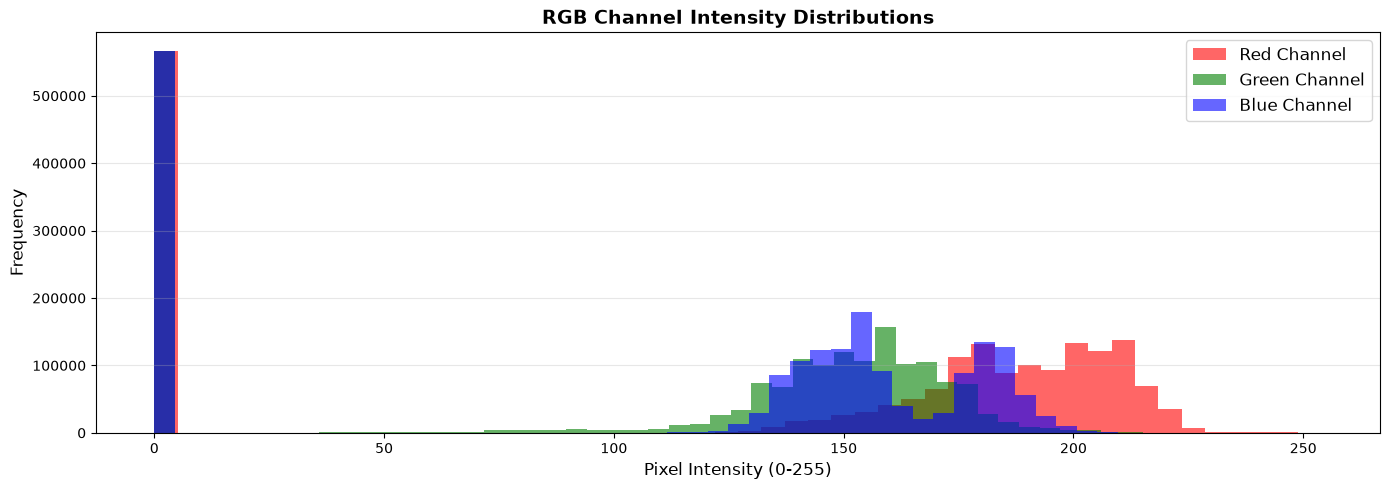

In [13]:
plt.figure(figsize=(14, 5))
plt.hist(r_pixels, bins=50, color='red', alpha=0.6, label='Red Channel')
plt.hist(g_pixels, bins=50, color='green', alpha=0.6, label='Green Channel')
plt.hist(b_pixels, bins=50, color='blue', alpha=0.6, label='Blue Channel')
plt.title('RGB Channel Intensity Distributions', fontsize=14, fontweight='bold')
plt.xlabel('Pixel Intensity (0-255)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EDA_SAVE_DIR, 'fig5_rgb_channels.png'), dpi=300)
plt.show()

"The dataset comprises a total of 27,558 microscopic blood smear images, evenly distributed between 13,779 parasitized (infected) cells and 13,779 uninfected (healthy) cells, representing a perfectly balanced class distribution (50.00% each). The raw images are captured in 3-channel RGB format. Dimension analysis reveals that the raw image heights range from [Min] to [Max] pixels (Mean: [Mean]), necessitating a standardized resizing step to [130x130] for uniform neural network input. Exploratory Data Analysis (EDA) of the RGB channels indicates that the [Red/Green/Blue] channel exhibits the highest variance, highlighting the prominence of [color] stains used in Giemsa-stained smears."

### **Create Training Data**

In [14]:
training_data = []

def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category)
        print(f"Processing {category}...")
        
        for img in os.listdir(path)[:1000]:  # Only process first 1000 images per category
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                # Normalize to [0, 1] and use float32 to save RAM
                new_array = new_array / 255.0 
                training_data.append([new_array, class_num])
            except Exception as e:
                pass
    print("Finished processing all categories.")

create_training_data()
print(f"Total images loaded: {len(training_data)}")

Processing Parasitized...
Processing Uninfected...
Finished processing all categories.
Total images loaded: 2000


### **Shuffle Data**

In [15]:
random.shuffle(training_data)

### **Separate Features (X) and Labels (y)**

In [16]:
X = []
y = []

for features, label in training_data:
    X.append(features)
    y.append(label)

# Convert to numpy arrays
X = np.array(X, dtype=np.float32) # float32 saves 50% memory
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2000, 130, 130, 3)
y shape: (2000,)


### **Save Data Safely (Avoids MemoryError)**

In [17]:
print("Saving data using NumPy...")
np.save("X_malaria.npy", X)
np.save("y_malaria.npy", y)
print("✓ Data saved successfully!")

Saving data using NumPy...
✓ Data saved successfully!


## **3. Train the Model (Keras CNN)**

### **Cell 13: Imports & Load Data**

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

X = np.load("X_malaria.npy")
y = np.load("y_malaria.npy")

### **Build and Train CNN**

In [19]:
model = Sequential()

model.add(Conv2D(64, (3, 3), input_shape=X.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation("relu"))
model.add(Dropout(0.5))

model.add(Dense(1)) # Binary classification
model.add(Activation('sigmoid'))

model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])

# Train the model
history = model.fit(X, y, batch_size=32, epochs=10, validation_split=0.1)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 449ms/step - accuracy: 0.5344 - loss: 0.7195 - val_accuracy: 0.5100 - val_loss: 0.6862
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 418ms/step - accuracy: 0.6161 - loss: 0.6545 - val_accuracy: 0.6350 - val_loss: 0.6441
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 26s 449ms/step - accuracy: 0.6689 - loss: 0.6059 - val_accuracy: 0.6150 - val_loss: 0.6643
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 25s 440ms/step - accuracy: 0.7156 - loss: 0.5528 - val_accuracy: 0.6150 - val_loss: 0.6675
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 423ms/step - accuracy: 0.7711 - loss: 0.4771 - val_accuracy: 0.6300 - val_loss: 0.6711
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 493ms/step - accuracy: 0.8200 - loss: 0.4006 - val_accuracy: 0.6450 - val_loss: 0.7163
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 25s 431ms/step - accuracy: 0.8711 - loss: 0.3156 - val_accuracy: 0.6400 - val_loss: 0.8225
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 418ms/step - accuracy: 0.8961 - loss: 0.2523 - val_accu

## **4. Prediction and Model Evaluation Section**

### **Load Data and Split**

In [20]:
X = np.load("X_malaria.npy")
y = np.load("y_malaria.npy")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 1600
Test set size: 400


### **Make Predictions**

In [21]:
predictions = model.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int).flatten()
prediction_probabilities = predictions.flatten()

print("\n=== PREDICTION RESULTS ===")
print(f"Total predictions: {len(predicted_classes)}")
print(f"Predicted as Uninfected: {np.sum(predicted_classes == 0)}")
print(f"Predicted as Parasitized: {np.sum(predicted_classes == 1)}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step

=== PREDICTION RESULTS ===
Total predictions: 400
Predicted as Uninfected: 205
Predicted as Parasitized: 195


### **Performance Metrics**

In [22]:
accuracy = accuracy_score(y_test, predicted_classes)
precision = precision_score(y_test, predicted_classes, average='weighted')
recall = recall_score(y_test, predicted_classes, average='weighted')
f1 = f1_score(y_test, predicted_classes, average='weighted')

cm = confusion_matrix(y_test, predicted_classes)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_test, predicted_classes)
kappa = cohen_kappa_score(y_test, predicted_classes)
roc_auc = roc_auc_score(y_test, prediction_probabilities)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:           {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:          {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall (Sensitivity): {recall:.4f} ({recall*100:.2f}%)")
print(f"Specificity:        {specificity:.4f} ({specificity*100:.2f}%)")
print(f"F1-Score:           {f1:.4f}")
print(f"MCC:                {mcc:.4f}")
print(f"Cohen's Kappa:      {kappa:.4f}")
print(f"ROC AUC:            {roc_auc:.4f}")
print("="*60)


MODEL PERFORMANCE METRICS
Accuracy:           0.9675 (96.75%)
Precision:          0.9678 (96.78%)
Recall (Sensitivity): 0.9675 (96.75%)
Specificity:        0.9800 (98.00%)
F1-Score:           0.9675
MCC:                0.9353
Cohen's Kappa:      0.9350
ROC AUC:            0.9885


In [23]:
# Cell 19: Classification Report
target_names = ['Uninfected', 'Parasitized']
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, predicted_classes, target_names=target_names))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Uninfected       0.96      0.98      0.97       200
 Parasitized       0.98      0.95      0.97       200

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



### **Plot the Confusion Matrix**

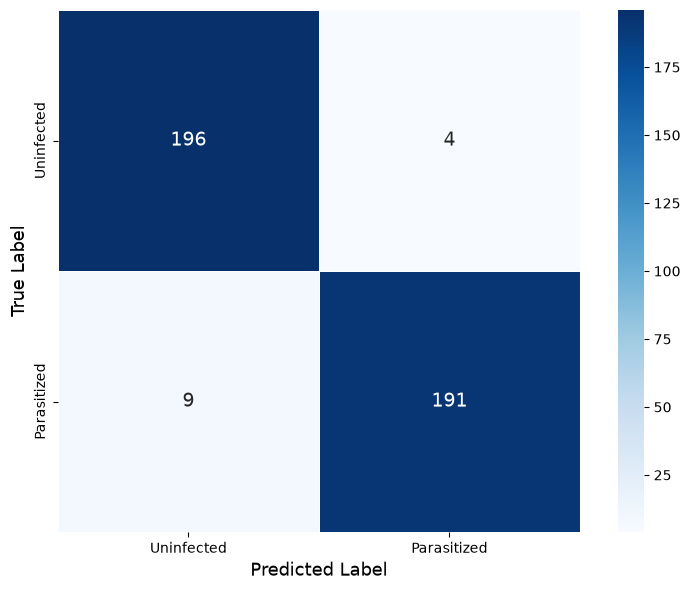

In [24]:
def plot_confusion_matrix(cm, classes, normalize=False,
                          #title='Confusion Matrix',
                          cmap=plt.cm.Blues,
                          save_path='confusion_matrix.png'):
    plt.figure(figsize=(8, 6))
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(
        cm,
        annot=True,
        fmt='.2f' if normalize else 'd',
        cmap=cmap,
        xticklabels=classes,
        yticklabels=classes,
        linewidths=0.5,
        square=True,
        cbar=True,
        annot_kws={"size": 14}
    )
    #plt.title(title, fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=13)
    plt.xlabel('Predicted Label', fontsize=13)
    plt.tight_layout()
    # Save BEFORE showing
    plt.savefig(
        save_path,
        dpi=600,                # Publication quality
        bbox_inches='tight',
        facecolor='white'
    )
    plt.show()
# Save figure
plot_confusion_matrix(
    cm,
    classes=target_names,
    #title='Confusion Matrix',
    save_path='confusion_matrix.png'
)

### **ROC Curve**

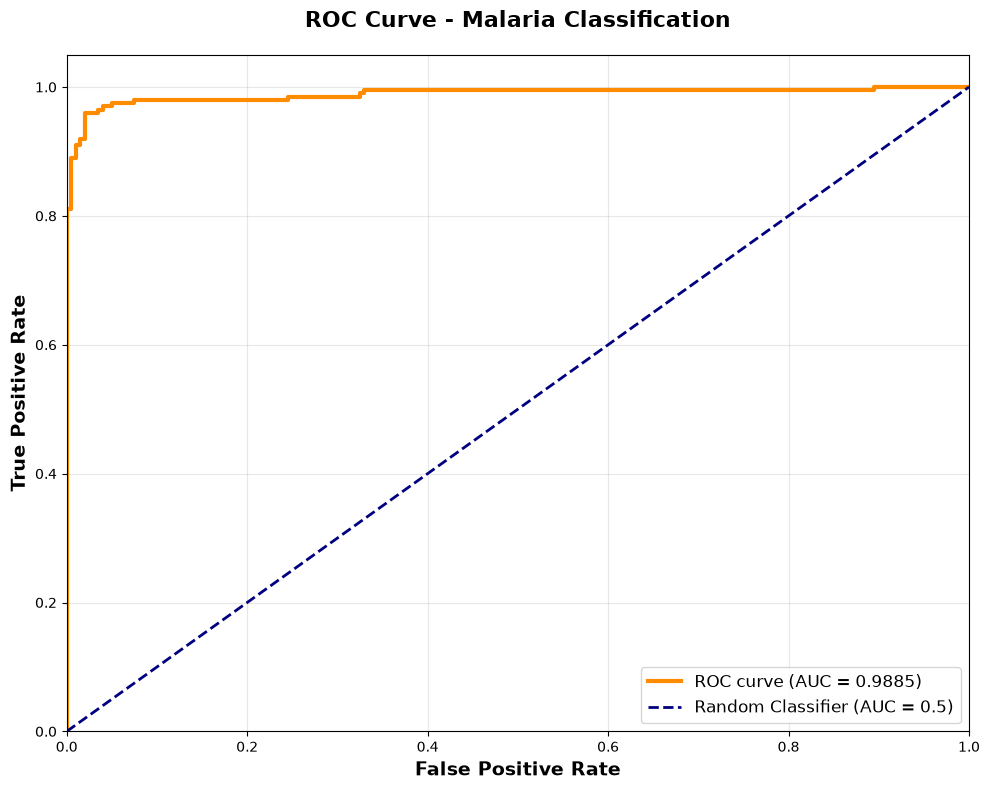

In [25]:
fpr, tpr, _ = roc_curve(y_test, prediction_probabilities)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Malaria Classification', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Precision-Recall Curve**

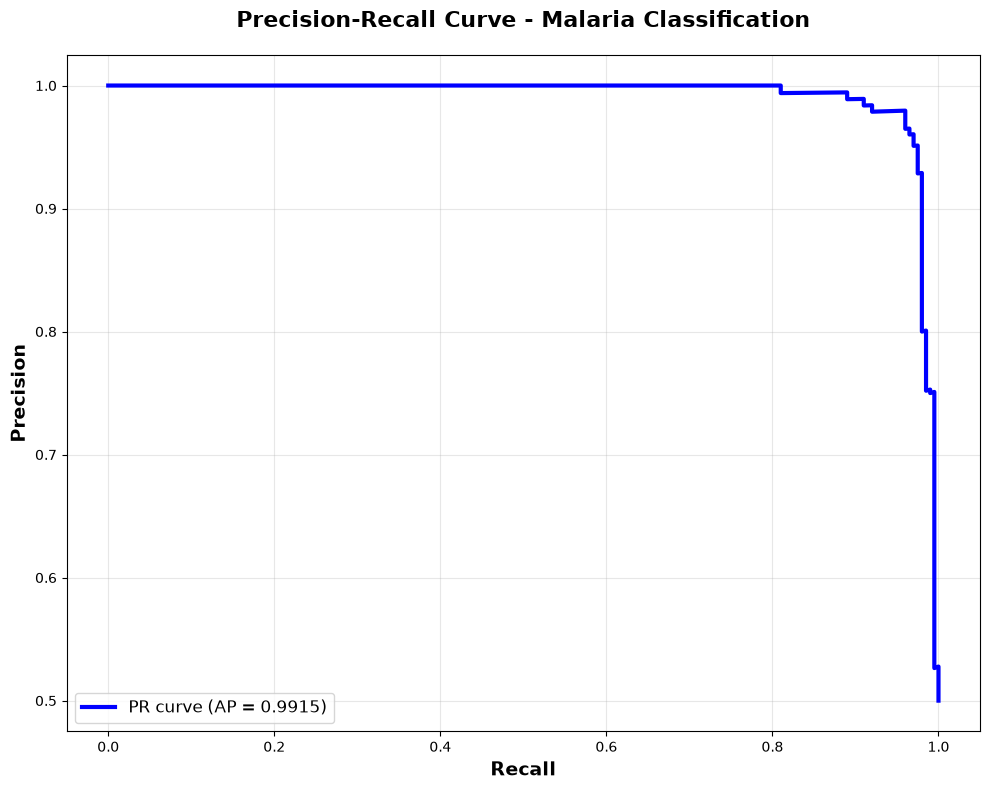

In [26]:
precision_pr, recall_pr, _ = precision_recall_curve(y_test, prediction_probabilities)
avg_precision = auc(recall_pr, precision_pr)

plt.figure(figsize=(10, 8))
plt.plot(recall_pr, precision_pr, color='blue', lw=3, label=f'PR curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall', fontsize=14, fontweight='bold')
plt.ylabel('Precision', fontsize=14, fontweight='bold')
plt.title('Precision-Recall Curve - Malaria Classification', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower left", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Metrics Bar Chart**

In [27]:
metrics_dict = {
    'Accuracy': float(np.mean(accuracy)),
    'Precision': float(np.mean(precision)),
    'Recall': float(np.mean(recall)),
    'Specificity': float(np.mean(specificity)),
    'F1-Score': float(np.mean(f1)),
    'MCC': float(np.mean(mcc)),
    'ROC AUC': float(np.mean(roc_auc))
}

In [28]:
import pandas as pd

metrics_df = pd.DataFrame(
    metrics_dict.items(),
    columns=["Metric", "Value"]
)

metrics_df

,Metric,Value
0,Accuracy,0.967500
1,Precision,0.967792
2,Recall,0.967500
3,Specificity,0.980000
4,F1-Score,0.967495
5,MCC,0.935292
6,ROC AUC,0.988475


### **Plot the Performance Metrics**

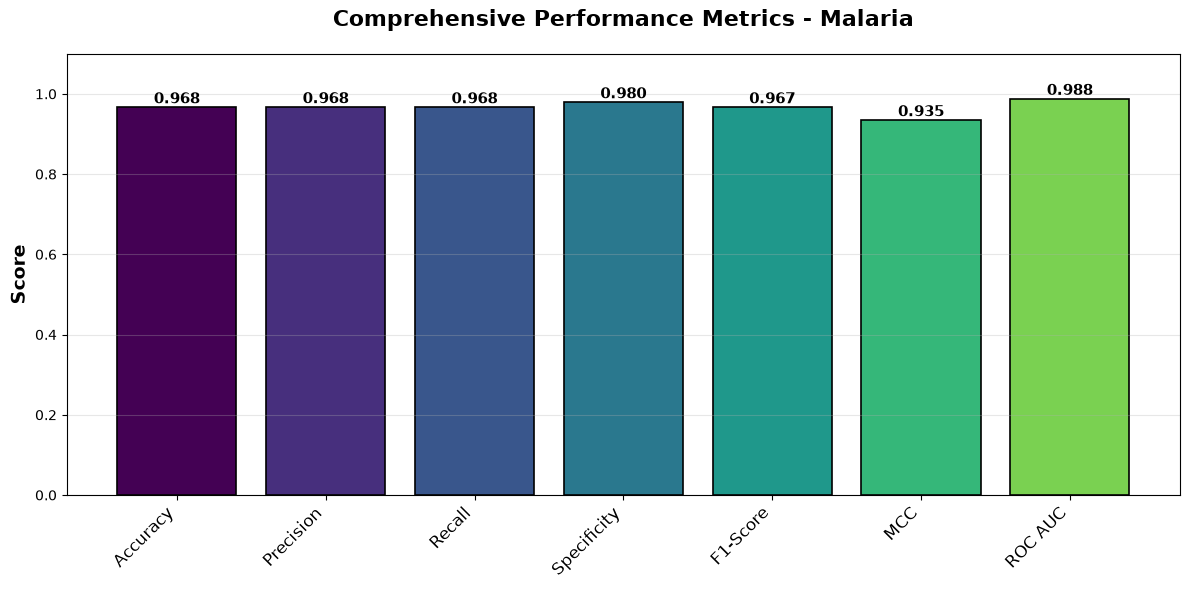

In [29]:
plt.figure(figsize=(12, 6))
names = list(metrics_dict.keys())
values = list(metrics_dict.values())
colors = plt.cm.viridis(np.linspace(0, 0.8, len(values)))

bars = plt.bar(names, values, color=colors, edgecolor='black', linewidth=1.2)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim([0, 1.1])
plt.ylabel('Score', fontsize=14, fontweight='bold')
plt.title('Comprehensive Performance Metrics - Malaria', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### **Plot the Model's Accuracy and Loss**


PLOTTING TRAINING HISTORY (ACCURACY & LOSS)
✓ Training history plot saved to: results\training_history_curves.png


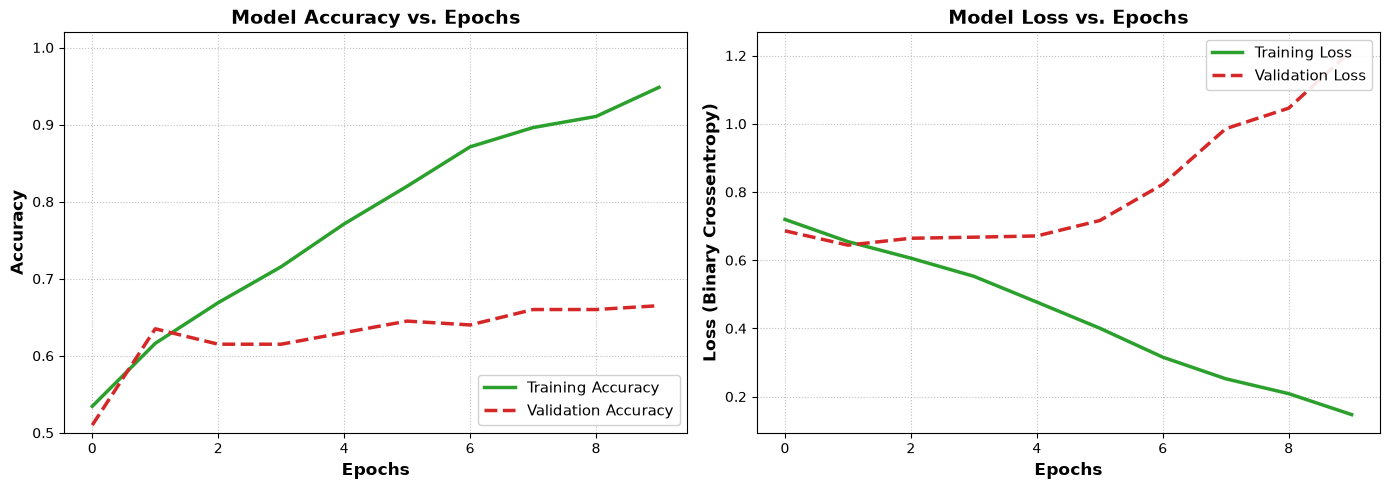


TRAINING HISTORY PLOTTING COMPLETED!


In [30]:
print("\n" + "="*70)
print("PLOTTING TRAINING HISTORY (ACCURACY & LOSS)")
print("="*70)

# Ensure the results directory exists
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: ACCURACY VS EPOCHS ---
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2.5)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#d62728', linewidth=2.5, linestyle='--')
axes[0].set_title('Model Accuracy vs. Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11, framealpha=0.9)
axes[0].grid(True, linestyle=':', alpha=0.8)
axes[0].set_ylim([0.5, 1.02]) # Adjust the lower limit if your model starts lower

# --- PLOT 2: LOSS VS EPOCHS ---
axes[1].plot(history.history['loss'], label='Training Loss', color='#2ca02c', linewidth=2.5)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#d62728', linewidth=2.5, linestyle='--')
axes[1].set_title('Model Loss vs. Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss (Binary Crossentropy)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=11, framealpha=0.9)
axes[1].grid(True, linestyle=':', alpha=0.8)

# Adjust layout and save
plt.tight_layout()
plot_path = os.path.join(results_dir, 'training_history_curves.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Training history plot saved to: {plot_path}")

# Display the plot
plt.show()

print("\n" + "="*70)
print("TRAINING HISTORY PLOTTING COMPLETED!")
print("="*70)